## Análise — Bubble 

Notebook para análise de variação dos parâmetros do Bubble.

- Versão do simulador que automatiza alguns passos para facilitar a análise de variação de parâmetros.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Any

from bubble import BubbleModel, DEFAULT_CONFIG, create_model
from bubble.affinity import cosine_similarity, dot_product
from bubble.selection import select_by_max_degree, select_randomly
from bubble.messages import opposite_uniform_message, opposite_unique_message
from bubble.metrics import cross_group_connectivity, modularity_value, assortativity_value
from bubble.scaling import constant_scaling, linear_scaling, log_scaling, power_law_scaling, sqrt_scaling

In [2]:
metric_options = {
    'cross_group_connectivity': cross_group_connectivity,
    'modularity_value': modularity_value,
    'assortativity_value': assortativity_value
}

In [3]:
PARAM_SPACE = {
    "num_nodes": [10, 20, 35, 50, 75, 100],
    "words_per_node": [(4,4), (7,7), (12,12), (25,25), (50,50), (100,100)],
    "affinity_level": [0.1, 0.2, 0.3, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95],
    "beta": [0.2, 0.4, 0.6, 0.8, 1.0],
    "gamma": [0.2, 0.4, 0.6, 0.8, 1.0],
    "affinity": [cosine_similarity, dot_product],
    "influencer_selection": [select_by_max_degree, select_randomly],
    "influencer_scaling": [constant_scaling(2), constant_scaling(4), linear_scaling(0.1), log_scaling(2)],
    "bubble_burst_metric_name": ['cross_group_connectivity', 'modularity_value', 'assortativity_value'],
    "message_generator": [opposite_uniform_message, opposite_unique_message],
    "num_iterations": [5, 10, 20, 50, 100, 200],
    "alphaL": [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    "alphaR": [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
}

In [4]:
def variate_parameters(param_space: dict[str, list|Any], samples: list[str|list[str]], varying: str|list[str], num_runs: int = 10, fixed: dict[str, Any]|None = None) -> None:
    if fixed is None:
        fixed = {}

    varying_key = varying
    varying_label = varying
    if isinstance(varying, list):
        varying_key = varying[0]
        varying_label = varying[1]

    display_fixed = {}
    fixed_parsed = {}
    for k, v in fixed.items():
        if isinstance(v, list) and len(v) == 2 and isinstance(v[1], str):
            fixed_parsed[k] = v[0]
            if v[1] != "":
                display_fixed[k] = v[1]
        else:
            fixed_parsed[k] = v
            display_fixed[k] = k

    display_samples = {}
    samples_parsed: list[str] = []
    for s in samples:
        if isinstance(s, list):
            key, placeholder = s[0], s[1]
            samples_parsed.append(key)
            if placeholder != "":
                display_samples[key] = placeholder
        else:
            samples_parsed.append(s)
            display_samples[s] = s

    if varying_key not in param_space:
        raise ValueError(f"Parameter '{varying_key}' not found in parameter space.")
    
    def select_with_precedence(param: str) -> Any:
        if param in fixed_parsed:
            return fixed_parsed[param]
        elif param in samples_parsed:
            return param_space[param][np.random.randint(0, len(param_space[param]))]
        elif param in DEFAULT_CONFIG:
            return DEFAULT_CONFIG[param]
        else:
            return param_space[param][0]
    
    cols = 1
    rows = int(np.ceil(num_runs / cols)) 
    fig, axes = plt.subplots(rows, cols, figsize=(24 * cols, 5 * rows), squeeze=False)
    axes = axes.flatten()

    all_keys = set(DEFAULT_CONFIG.keys()).union(param_space.keys())

    for run_index in range(num_runs):
        CURRENT_CONFIG: dict[str, Any] = {
            key: select_with_precedence(key) for key in all_keys
        }

        print(f"\n--- Run {run_index + 1}/{num_runs} ---")
        print("Base Config:")
        for k, v in CURRENT_CONFIG.items():
            if k != varying_key:
                val_rep = getattr(v, '__name__', str(v))
                print(f"  {k}: {val_rep}")
        
        first_cross_edge_time = []

        ax = axes[run_index]
        n_iters = CURRENT_CONFIG['num_iterations']
        msg_generator = CURRENT_CONFIG['message_generator']
        
        varying_values = param_space[varying_key]
        colors = plt.get_cmap('tab10')(np.linspace(0, 1, len(varying_values)))

        for i, value in enumerate(varying_values):
            CURRENT_CONFIG[varying_key] = value
            
            varying_config = create_model(CURRENT_CONFIG)
            model = BubbleModel(varying_config)
            
            wpn = model.words_per_node
            msg0 = msg_generator(wpn, 0)
            msg1 = msg_generator(wpn, 1)
            
            model.run(n_iters, msg0, msg1)

            idx_l = np.where(model.labels == 0)[0][0]
            idx_r = np.where(model.labels == 1)[0][0]
            
            perf_l = model.G.nodes[idx_l]['p']
            perf_r = model.G.nodes[idx_r]['p']

            print(f"[{varying_label}: {value}]")
            print(f"  > First Cross Edge: {model.cross_edge_time}")
            print(f"  > Sample from L (Node {idx_l}): {np.round(perf_l, 4)}")
            print(f"  > Sample from R (Node {idx_r}): {np.round(perf_r, 4)}")
            print("-" * 40)

            label_name = getattr(value, '__name__', str(value))
            first_cross_edge_time.append(model.cross_edge_time)
            
            model.plot_bubble_burst(
                ax=ax, 
                show=False,
                title=f"Run {run_index + 1}",
                label=f"{varying_label}: {label_name}",
                color=colors[i]
            )
            
        ax.grid(True, linestyle='--', alpha=0.6)
        primary_legend = ax.legend(fontsize='small', loc='upper left', bbox_to_anchor=(1.0, 1))
        ax.add_artist(primary_legend)
        
        secondary_handles = []
        secondary_labels = []

        for s in display_samples:
            val = CURRENT_CONFIG[s]
            val_str = getattr(val, '__name__', str(val))
            dummy_line, = ax.plot([], [], marker="", ls="")
            secondary_handles.append(dummy_line)
            secondary_labels.append(f"{display_samples[s]}: {val_str}")

        for k in display_fixed:
            if k in display_samples: continue 
            val = CURRENT_CONFIG[k]
            val_str = getattr(val, '__name__', str(val))
            dummy_line, = ax.plot([], [], marker="", ls="")
            secondary_handles.append(dummy_line)
            secondary_labels.append(f"{display_fixed[k]}: {val_str}")
            
        if secondary_labels:
            ax.legend(
                handles=secondary_handles, 
                labels=secondary_labels, 
                loc='lower left', 
                bbox_to_anchor=(1.0, 0),
                fontsize='small'
            )

    for i in range(num_runs, len(axes)):
        fig.delaxes(axes[i])

    fig.subplots_adjust(left=0.05, right=0.4, wspace=0.1, hspace=0.3)
    plt.show()


--- Run 1/10 ---
Base Config:
  influencer_scaling: const_rule
  num_iterations: 50
  num_nodes: 50
  beta: 0.8
  labels: []
  words_per_node: (15, 15)
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  influencer_selection: select_by_max_degree
  gamma: 0.6
  affinity: cosine_similarity
  alphaL: None
  alphaR: None
  bubble_burst_metric_name: cross_group_connectivity
[τ: 0.1]
  > First Cross Edge: 1
  > Sample from L (Node 1): [0.0008 0.0008 0.0008 0.0008 0.0008 0.0008 0.0008 0.0008 0.0008 0.0008
 0.0008 0.0008 0.0008 0.0008 0.0008 0.0659 0.0659 0.0659 0.0659 0.0659
 0.0659 0.0659 0.0659 0.0659 0.0659 0.0659 0.0659 0.0659 0.0659 0.0659]
  > Sample from R (Node 0): [0.0659 0.0659 0.0659 0.0659 0.0659 0.0659 0.0659 0.0659 0.0659 0.0659
 0.0659 0.0659 0.0659 0.0659 0.0659 0.0008 0.0008 0.0008 0.0008 0.0008
 0.0008 0.0008 0.0008 0.0008 0.0008 0.0008 0.0008 0.0008 0.0008 0.0008]
----------------------------------------
[τ: 0.2]
  > First Cross

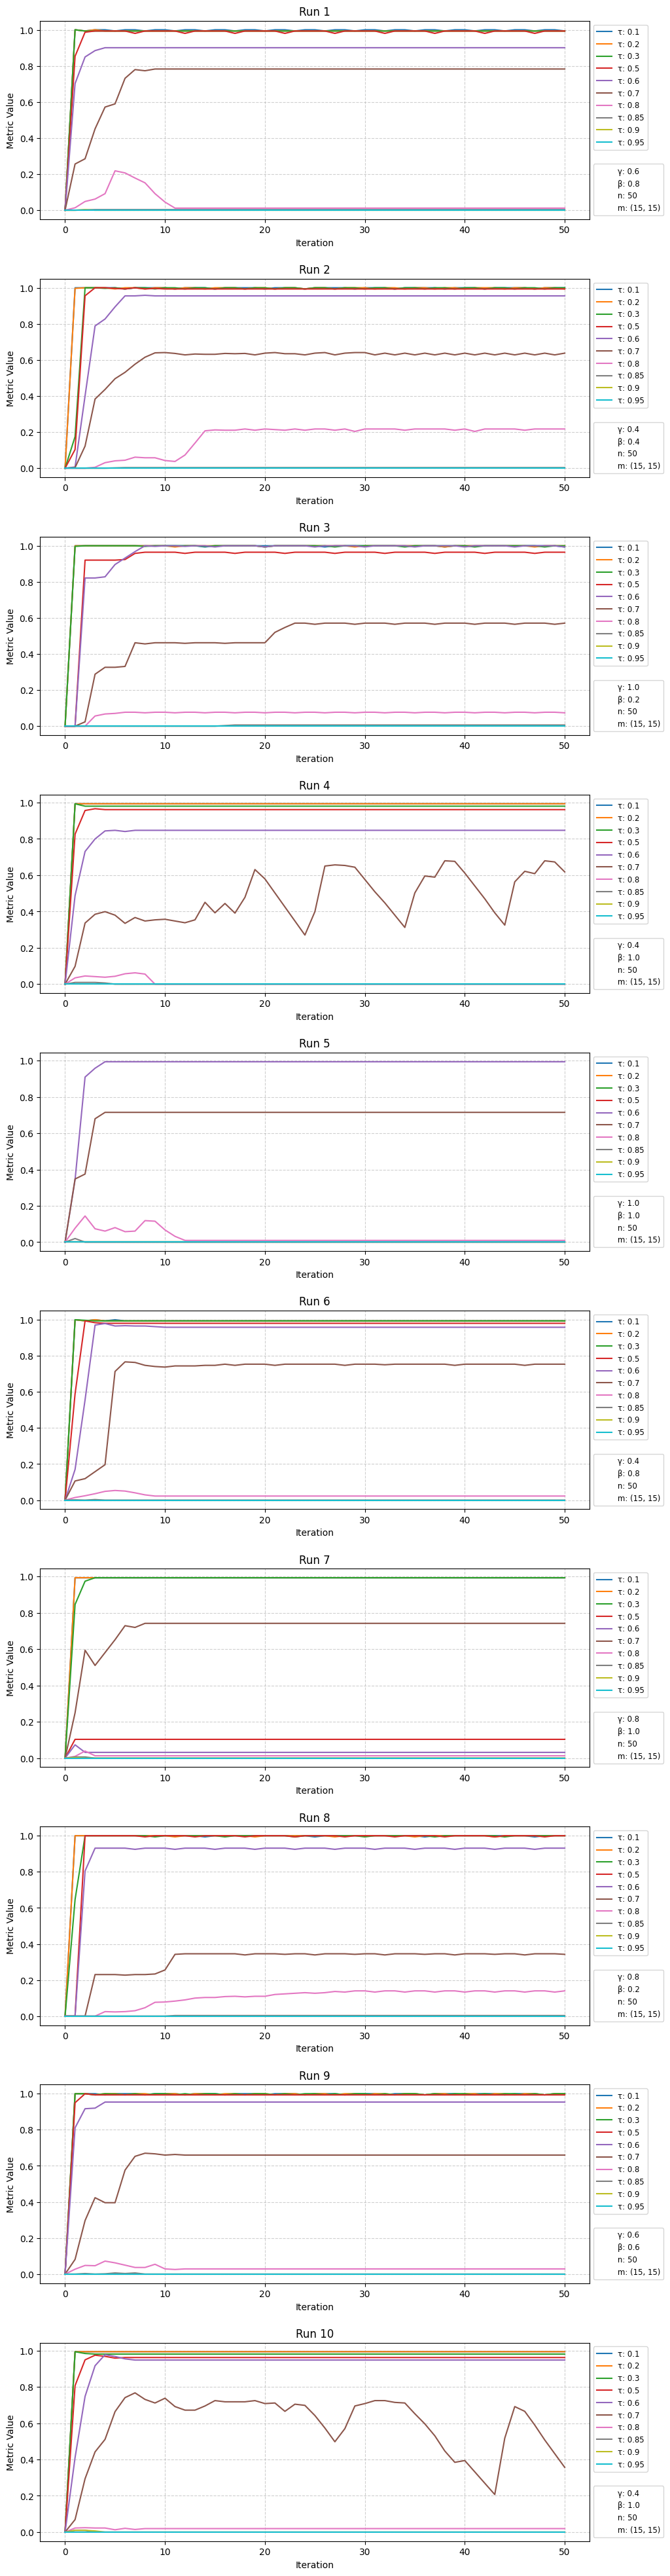

In [5]:
variate_parameters(
    param_space=PARAM_SPACE,
    samples=[['gamma','γ'], ['beta','β']],
    varying=['affinity_level','τ'],
    fixed={'num_nodes': [50,'n'], 'words_per_node': [(15,15),'m'], 'num_iterations': [50, '']},
    num_runs=10
)

# Beta e Gama são iguais para ambos os rótulos


--- Run 1/1 ---
Base Config:
  influencer_scaling: const_rule
  num_iterations: 50
  num_nodes: 50
  labels: []
  words_per_node: (15, 15)
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  influencer_selection: select_by_max_degree
  gamma: 0.2
  affinity: cosine_similarity
  alphaL: None
  alphaR: None
  affinity_level: 0.7
  bubble_burst_metric_name: cross_group_connectivity
[β: 0.2]
  > First Cross Edge: 4
  > Sample from L (Node 1): [0.0177 0.0181 0.0178 0.018  0.0179 0.0181 0.0182 0.018  0.0178 0.0186
 0.0186 0.0182 0.018  0.0182 0.0177 0.0486 0.0485 0.0485 0.0487 0.0485
 0.0486 0.0487 0.0486 0.0485 0.0485 0.0488 0.0486 0.0487 0.0486 0.0486]
  > Sample from R (Node 0): [0.0453 0.0457 0.0454 0.0456 0.0455 0.0457 0.0458 0.0456 0.0454 0.0462
 0.0462 0.0457 0.0456 0.0458 0.0453 0.021  0.0209 0.0209 0.0211 0.0209
 0.021  0.0211 0.021  0.0209 0.0209 0.0212 0.021  0.0211 0.021  0.021 ]
----------------------------------------
[β: 0.4]
  > Fi

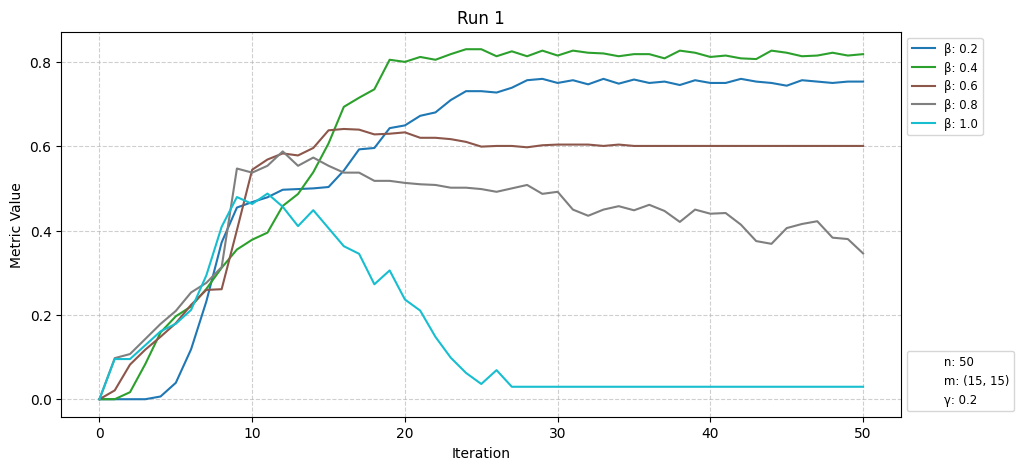

In [6]:
variate_parameters(
    param_space=PARAM_SPACE,
    samples=[],
    varying=['beta','β'],
    fixed={'num_nodes': [50,'n'], 'words_per_node': [(15,15),'m'], 'affinity_level': [0.7,''], 'gamma': [0.2,'γ'], 'num_iterations': [50, '']},
    num_runs=1
)


--- Run 1/1 ---
Base Config:
  influencer_scaling: const_rule
  num_iterations: 50
  num_nodes: 50
  labels: []
  words_per_node: (15, 15)
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  influencer_selection: select_by_max_degree
  gamma: 0.4
  affinity: cosine_similarity
  alphaL: None
  alphaR: None
  affinity_level: 0.7
  bubble_burst_metric_name: cross_group_connectivity
[β: 0.2]
  > First Cross Edge: 4
  > Sample from L (Node 0): [0.0242 0.0242 0.0241 0.0242 0.0242 0.0242 0.0242 0.0242 0.0242 0.0241
 0.0242 0.0242 0.0242 0.0241 0.0242 0.0425 0.0425 0.0425 0.0425 0.0425
 0.0425 0.0425 0.0425 0.0425 0.0425 0.0425 0.0425 0.0425 0.0425 0.0425]
  > Sample from R (Node 2): [0.0424 0.0425 0.0424 0.0424 0.0424 0.0425 0.0425 0.0424 0.0424 0.0424
 0.0424 0.0424 0.0424 0.0424 0.0424 0.0242 0.0242 0.0242 0.0242 0.0242
 0.0242 0.0242 0.0242 0.0242 0.0242 0.0242 0.0243 0.0242 0.0242 0.0242]
----------------------------------------
[β: 0.4]
  > Fi

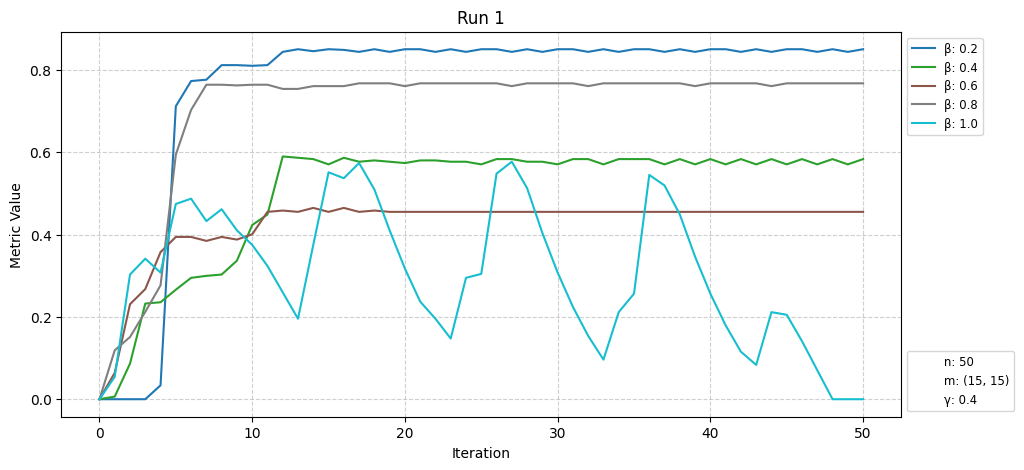

In [7]:
variate_parameters(
    param_space=PARAM_SPACE,
    samples=[],
    varying=['beta','β'],
    fixed={'num_nodes': [50,'n'], 'words_per_node': [(15,15),'m'], 'affinity_level': [0.7,''], 'gamma': [0.4,'γ'], 'num_iterations': [50, '']},
    num_runs=1
)


--- Run 1/1 ---
Base Config:
  influencer_scaling: const_rule
  num_iterations: 50
  num_nodes: 50
  labels: []
  words_per_node: (15, 15)
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  influencer_selection: select_by_max_degree
  gamma: 0.6
  affinity: cosine_similarity
  alphaL: None
  alphaR: None
  affinity_level: 0.7
  bubble_burst_metric_name: cross_group_connectivity
[β: 0.2]
  > First Cross Edge: 3
  > Sample from L (Node 0): [0.0215 0.0215 0.0215 0.0215 0.0215 0.0215 0.0215 0.0215 0.0215 0.0215
 0.0215 0.0215 0.0215 0.0215 0.0215 0.0452 0.0452 0.0452 0.0452 0.0452
 0.0452 0.0452 0.0452 0.0452 0.0452 0.0452 0.0452 0.0452 0.0452 0.0452]
  > Sample from R (Node 1): [0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.1511 0.0137 0.0505 0.2666 0.1272
 0.0775 0.0035 0.0235 0.0307 0.0968 0.011  0.0793 0.0546 0.0126 0.0015]
----------------------------------------
[β: 0.4]
  > First 

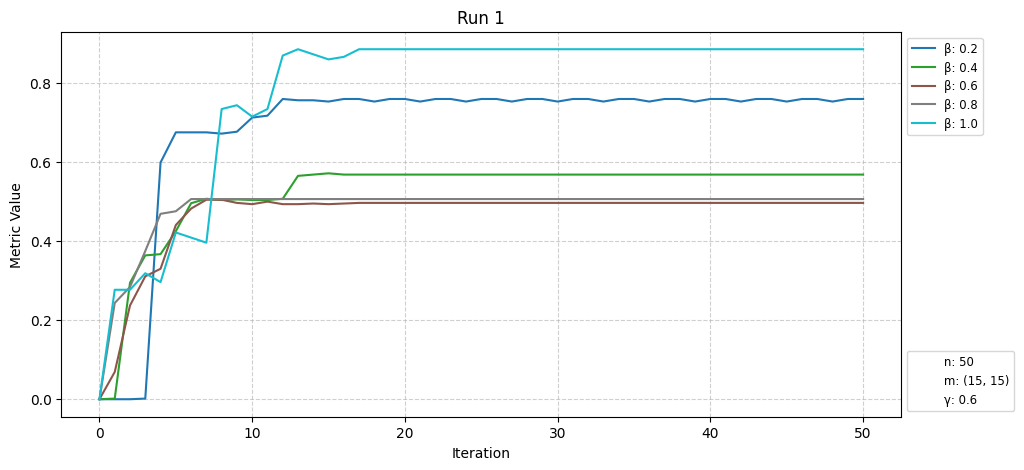

In [8]:
variate_parameters(
    param_space=PARAM_SPACE,
    samples=[],
    varying=['beta','β'],
    fixed={'num_nodes': [50,'n'], 'words_per_node': [(15,15),'m'], 'affinity_level': [0.7,''], 'gamma': [0.6,'γ'], 'num_iterations': [50, '']},
    num_runs=1
)


--- Run 1/1 ---
Base Config:
  influencer_scaling: const_rule
  num_iterations: 50
  num_nodes: 50
  labels: []
  words_per_node: (15, 15)
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  influencer_selection: select_by_max_degree
  gamma: 0.8
  affinity: cosine_similarity
  alphaL: None
  alphaR: None
  affinity_level: 0.7
  bubble_burst_metric_name: cross_group_connectivity
[β: 0.2]
  > First Cross Edge: 3
  > Sample from L (Node 3): [0.0305 0.0305 0.0305 0.0305 0.0305 0.0305 0.0305 0.0305 0.0305 0.0305
 0.0305 0.0305 0.0305 0.0305 0.0305 0.0362 0.0362 0.0362 0.0362 0.0362
 0.0362 0.0362 0.0362 0.0362 0.0362 0.0362 0.0362 0.0362 0.0362 0.0362]
  > Sample from R (Node 0): [0.0362 0.0362 0.0362 0.0362 0.0362 0.0362 0.0362 0.0362 0.0362 0.0362
 0.0362 0.0362 0.0362 0.0362 0.0362 0.0305 0.0305 0.0305 0.0305 0.0305
 0.0305 0.0305 0.0305 0.0305 0.0305 0.0305 0.0305 0.0305 0.0305 0.0305]
----------------------------------------
[β: 0.4]
  > Fi

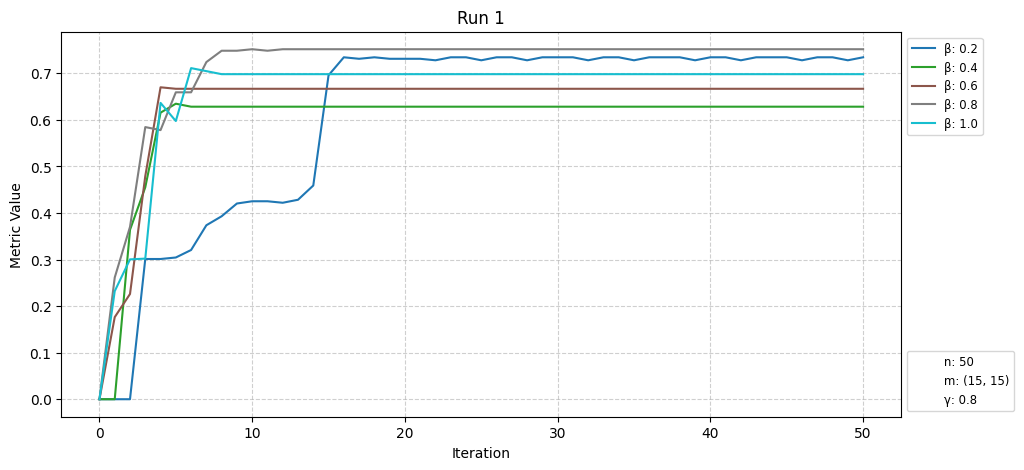

In [9]:
variate_parameters(
    param_space=PARAM_SPACE,
    samples=[],
    varying=['beta','β'],
    fixed={'num_nodes': [50,'n'], 'words_per_node': [(15,15),'m'], 'affinity_level': [0.7,''], 'gamma': [0.8,'γ'], 'num_iterations': [50, '']},
    num_runs=1
)


--- Run 1/1 ---
Base Config:
  influencer_scaling: const_rule
  num_iterations: 50
  num_nodes: 50
  labels: []
  words_per_node: (15, 15)
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  influencer_selection: select_by_max_degree
  gamma: 1.0
  affinity: cosine_similarity
  alphaL: None
  alphaR: None
  affinity_level: 0.7
  bubble_burst_metric_name: cross_group_connectivity
[β: 0.2]
  > First Cross Edge: 2
  > Sample from L (Node 0): [0.0334 0.0334 0.0334 0.0334 0.0334 0.0334 0.0334 0.0334 0.0334 0.0334
 0.0334 0.0334 0.0334 0.0334 0.0334 0.0333 0.0333 0.0333 0.0333 0.0333
 0.0333 0.0333 0.0333 0.0333 0.0333 0.0333 0.0333 0.0333 0.0333 0.0333]
  > Sample from R (Node 2): [0.0334 0.0334 0.0334 0.0334 0.0334 0.0334 0.0334 0.0334 0.0334 0.0334
 0.0334 0.0334 0.0334 0.0334 0.0334 0.0333 0.0333 0.0333 0.0333 0.0333
 0.0333 0.0333 0.0333 0.0333 0.0333 0.0333 0.0333 0.0333 0.0333 0.0333]
----------------------------------------
[β: 0.4]
  > Fi

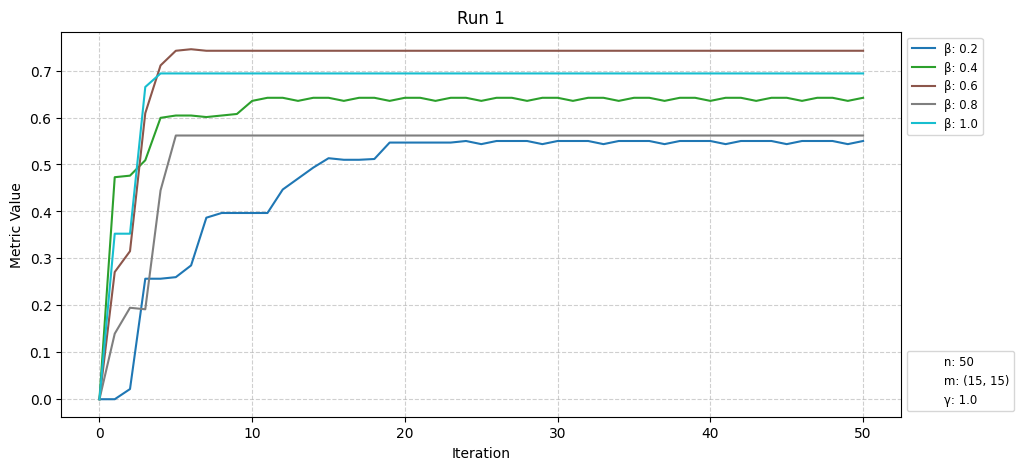

In [10]:
variate_parameters(
    param_space=PARAM_SPACE,
    samples=[],
    varying=['beta','β'],
    fixed={'num_nodes': [50,'n'], 'words_per_node': [(15,15),'m'], 'affinity_level': [0.7,''], 'gamma': [1.0,'γ'], 'num_iterations': [50, '']},
    num_runs=1
)


--- Run 1/1 ---
Base Config:
  influencer_scaling: const_rule
  num_iterations: 50
  num_nodes: 50
  beta: 0.2
  labels: []
  words_per_node: (15, 15)
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  influencer_selection: select_by_max_degree
  affinity: cosine_similarity
  alphaL: None
  alphaR: None
  affinity_level: 0.7
  bubble_burst_metric_name: cross_group_connectivity
[γ: 0.2]
  > First Cross Edge: 4
  > Sample from L (Node 0): [0.0219 0.022  0.0218 0.0218 0.022  0.0219 0.022  0.0219 0.0217 0.0218
 0.0219 0.0218 0.0218 0.0218 0.0218 0.0446 0.0454 0.0446 0.0446 0.0448
 0.0448 0.0451 0.0447 0.0448 0.0449 0.0449 0.0447 0.0448 0.0447 0.0448]
  > Sample from R (Node 4): [0.0473 0.0474 0.0472 0.0472 0.0474 0.0473 0.0474 0.0473 0.0471 0.0472
 0.0473 0.0472 0.0472 0.0472 0.0472 0.0192 0.02   0.0192 0.0192 0.0194
 0.0194 0.0197 0.0193 0.0194 0.0195 0.0195 0.0193 0.0194 0.0192 0.0194]
----------------------------------------
[γ: 0.4]
  > Fir

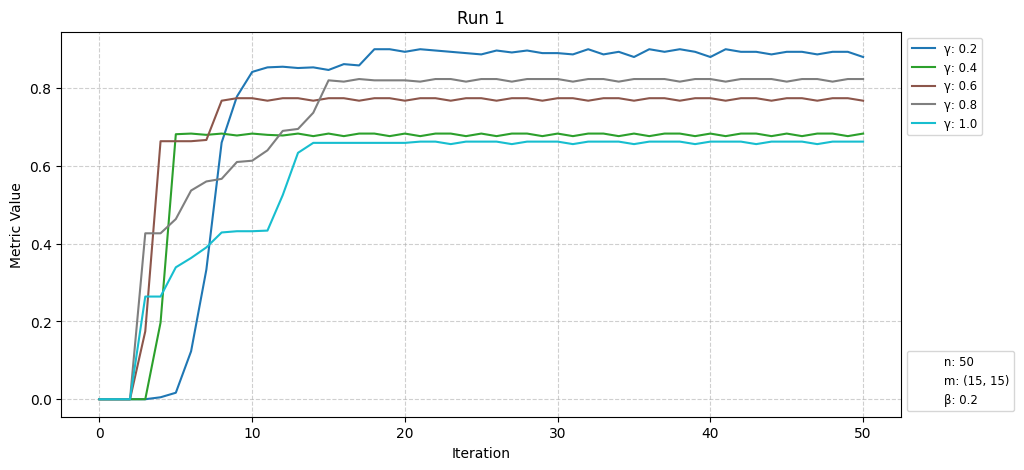

In [11]:
variate_parameters(
    param_space=PARAM_SPACE,
    samples=[],
    varying=['gamma','γ'],
    fixed={'num_nodes': [50,'n'], 'words_per_node': [(15,15),'m'], 'affinity_level': [0.7,''], 'beta': [0.2,'β'], 'num_iterations': [50, '']},
    num_runs=1
)


--- Run 1/1 ---
Base Config:
  influencer_scaling: const_rule
  num_iterations: 50
  num_nodes: 50
  beta: 0.4
  labels: []
  words_per_node: (15, 15)
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  influencer_selection: select_by_max_degree
  affinity: cosine_similarity
  alphaL: None
  alphaR: None
  affinity_level: 0.7
  bubble_burst_metric_name: cross_group_connectivity
[γ: 0.2]
  > First Cross Edge: 1
  > Sample from L (Node 2): [0.0211 0.0211 0.0211 0.0211 0.0211 0.0211 0.0211 0.0211 0.0211 0.0211
 0.0211 0.0211 0.0211 0.0211 0.0211 0.0456 0.0456 0.0456 0.0456 0.0456
 0.0456 0.0456 0.0456 0.0456 0.0456 0.0456 0.0456 0.0456 0.0456 0.0456]
  > Sample from R (Node 0): [0.0409 0.0409 0.0409 0.0409 0.041  0.0409 0.0409 0.0409 0.0409 0.0409
 0.0409 0.0409 0.0409 0.041  0.0409 0.0257 0.0257 0.0257 0.0257 0.0257
 0.0257 0.0257 0.0258 0.0257 0.0258 0.0257 0.0257 0.0257 0.0257 0.0257]
----------------------------------------
[γ: 0.4]
  > Fir

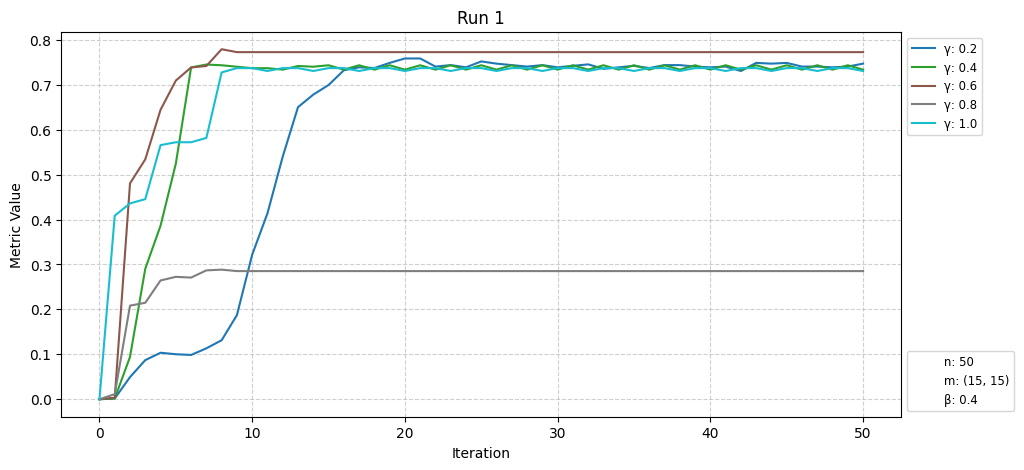

In [12]:
variate_parameters(
    param_space=PARAM_SPACE,
    samples=[],
    varying=['gamma','γ'],
    fixed={'num_nodes': [50,'n'], 'words_per_node': [(15,15),'m'], 'affinity_level': [0.7,''], 'beta': [0.4,'β'], 'num_iterations': [50, '']},
    num_runs=1
)


--- Run 1/1 ---
Base Config:
  influencer_scaling: const_rule
  num_iterations: 50
  num_nodes: 50
  beta: 0.6
  labels: []
  words_per_node: (15, 15)
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  influencer_selection: select_by_max_degree
  affinity: cosine_similarity
  alphaL: None
  alphaR: None
  affinity_level: 0.7
  bubble_burst_metric_name: cross_group_connectivity
[γ: 0.2]
  > First Cross Edge: 1
  > Sample from L (Node 0): [0.0375 0.0224 0.1083 0.0327 0.0167 0.035  0.0147 0.0344 0.0307 0.0162
 0.2291 0.0122 0.0521 0.0223 0.0217 0.0209 0.021  0.021  0.021  0.0209
 0.021  0.0209 0.0209 0.0209 0.0209 0.0209 0.0209 0.0209 0.0209 0.021 ]
  > Sample from R (Node 1): [0.0392 0.0392 0.0392 0.0392 0.0392 0.0392 0.0392 0.0392 0.0392 0.0392
 0.0392 0.0392 0.0392 0.0392 0.0392 0.0275 0.0275 0.0275 0.0275 0.0275
 0.0275 0.0275 0.0275 0.0275 0.0275 0.0275 0.0275 0.0275 0.0275 0.0275]
----------------------------------------
[γ: 0.4]
  > Fir

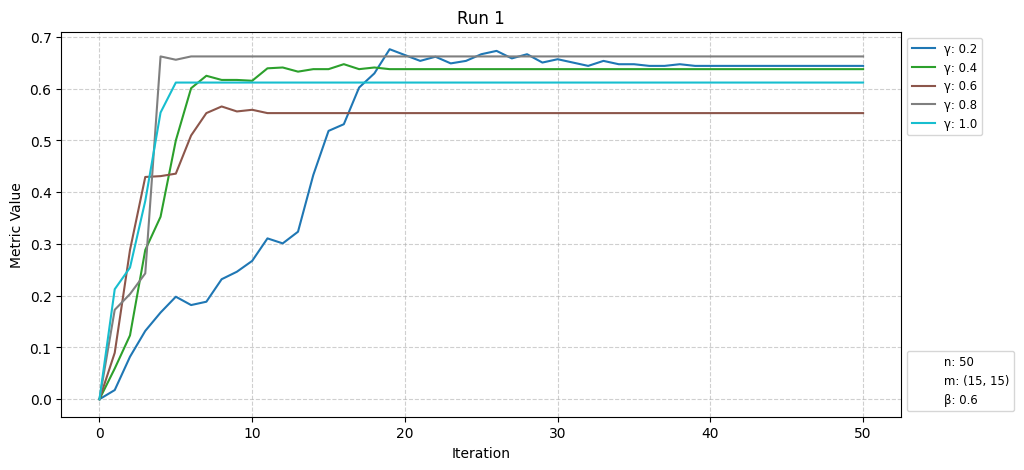

In [13]:
variate_parameters(
    param_space=PARAM_SPACE,
    samples=[],
    varying=['gamma','γ'],
    fixed={'num_nodes': [50,'n'], 'words_per_node': [(15,15),'m'], 'affinity_level': [0.7,''], 'beta': [0.6,'β'], 'num_iterations': [50, '']},
    num_runs=1
)


--- Run 1/1 ---
Base Config:
  influencer_scaling: const_rule
  num_iterations: 50
  num_nodes: 50
  beta: 0.8
  labels: []
  words_per_node: (15, 15)
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  influencer_selection: select_by_max_degree
  affinity: cosine_similarity
  alphaL: None
  alphaR: None
  affinity_level: 0.7
  bubble_burst_metric_name: cross_group_connectivity
[γ: 0.2]
  > First Cross Edge: 1
  > Sample from L (Node 0): [0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.0667 0.0667 0.0667 0.0667 0.0667
 0.0667 0.0667 0.0667 0.0667 0.0667 0.0667 0.0667 0.0667 0.0667 0.0667]
  > Sample from R (Node 1): [0.0667 0.0667 0.0667 0.0667 0.0667 0.0667 0.0667 0.0667 0.0667 0.0667
 0.0667 0.0667 0.0667 0.0667 0.0667 0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.    ]
----------------------------------------
[γ: 0.4]
  > First Cross

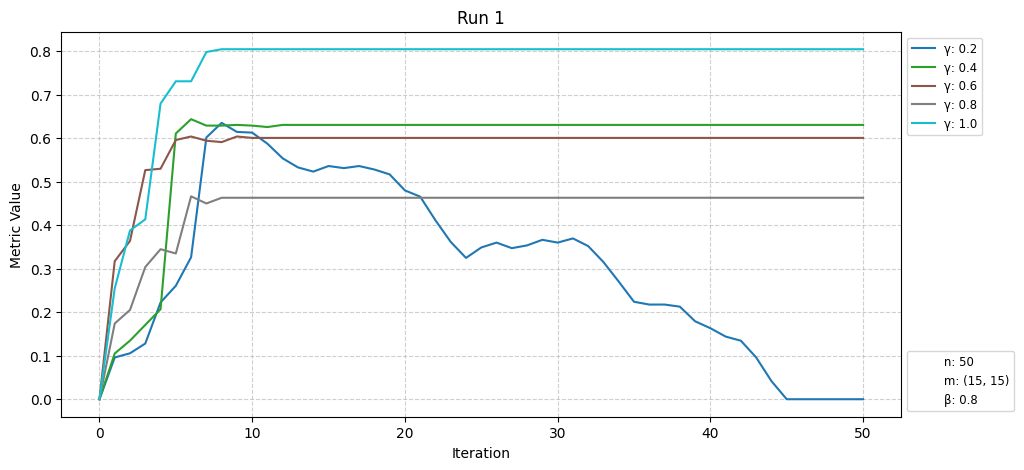

In [14]:
variate_parameters(
    param_space=PARAM_SPACE,
    samples=[],
    varying=['gamma','γ'],
    fixed={'num_nodes': [50,'n'], 'words_per_node': [(15,15),'m'], 'affinity_level': [0.7,''], 'beta': [0.8,'β'], 'num_iterations': [50, '']},
    num_runs=1
)


--- Run 1/1 ---
Base Config:
  influencer_scaling: const_rule
  num_iterations: 50
  num_nodes: 50
  beta: 1.0
  labels: []
  words_per_node: (15, 15)
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  influencer_selection: select_by_max_degree
  affinity: cosine_similarity
  alphaL: None
  alphaR: None
  affinity_level: 0.7
  bubble_burst_metric_name: cross_group_connectivity
[γ: 0.2]
  > First Cross Edge: 1
  > Sample from L (Node 4): [0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.0667 0.0667 0.0667 0.0667 0.0667
 0.0667 0.0667 0.0667 0.0667 0.0667 0.0667 0.0667 0.0667 0.0667 0.0667]
  > Sample from R (Node 0): [0.0667 0.0667 0.0667 0.0667 0.0667 0.0667 0.0667 0.0667 0.0667 0.0667
 0.0667 0.0667 0.0667 0.0667 0.0667 0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.    ]
----------------------------------------
[γ: 0.4]
  > First Cross

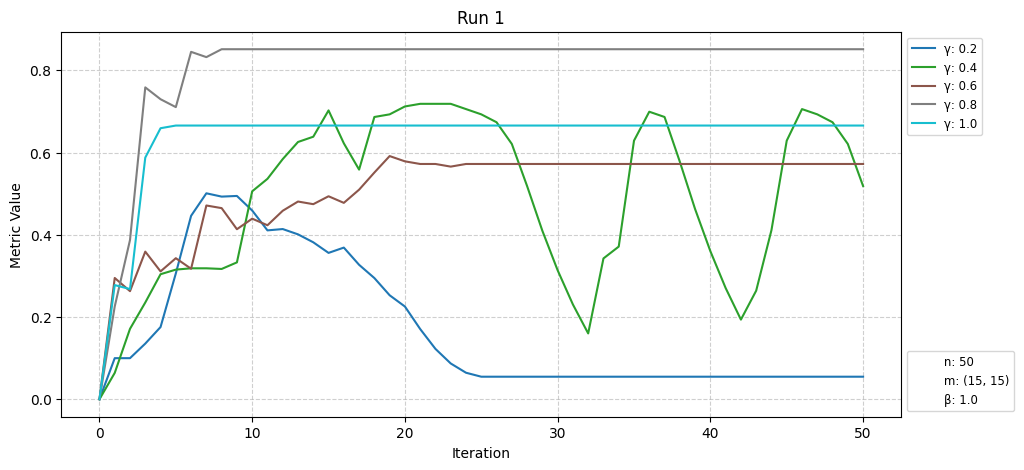

In [15]:
variate_parameters(
    param_space=PARAM_SPACE,
    samples=[],
    varying=['gamma','γ'],
    fixed={'num_nodes': [50,'n'], 'words_per_node': [(15,15),'m'], 'affinity_level': [0.7,''], 'beta': [1.0,'β'], 'num_iterations': [50, '']},
    num_runs=1
)

# Beta Diferente Por Lado


--- Run 1/1 ---
Base Config:
  influencer_scaling: const_rule
  num_iterations: 50
  num_nodes: 50
  beta: (0.2, 0.8)
  labels: []
  words_per_node: (15, 15)
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  influencer_selection: select_by_max_degree
  affinity: cosine_similarity
  alphaL: None
  alphaR: None
  affinity_level: 0.7
  bubble_burst_metric_name: cross_group_connectivity
[γ: 0.2]
  > First Cross Edge: 1
  > Sample from L (Node 0): [0.027  0.027  0.027  0.0271 0.0271 0.0271 0.0271 0.0271 0.027  0.0271
 0.0271 0.027  0.027  0.027  0.0271 0.0396 0.0396 0.0396 0.0396 0.0396
 0.0396 0.0396 0.0396 0.0396 0.0396 0.0396 0.0396 0.0396 0.0396 0.0396]
  > Sample from R (Node 2): [0.0644 0.0644 0.0644 0.0644 0.0644 0.0644 0.0644 0.0644 0.0644 0.0644
 0.0644 0.0644 0.0644 0.0644 0.0644 0.0023 0.0023 0.0023 0.0023 0.0023
 0.0023 0.0023 0.0023 0.0023 0.0023 0.0023 0.0023 0.0023 0.0023 0.0023]
----------------------------------------
[γ: 0.4]


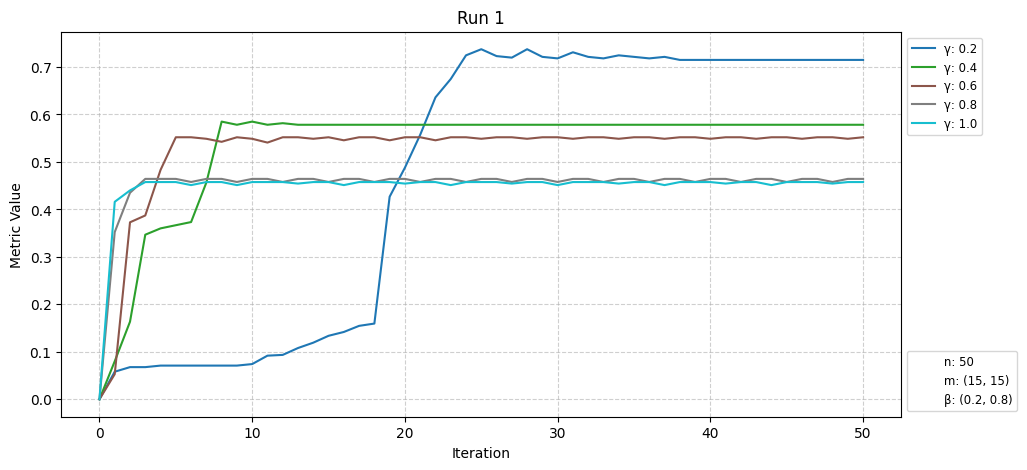

In [16]:
variate_parameters(
    param_space=PARAM_SPACE,
    samples=[],
    varying=['gamma','γ'],
    fixed={'num_nodes': [50,'n'], 'words_per_node': [(15,15),'m'], 'affinity_level': [0.7,''], 'beta': [(0.2,0.8),'β'], 'num_iterations': [50, '']},
    num_runs=1
)

# Gama Diferente Por Lado


--- Run 1/1 ---
Base Config:
  influencer_scaling: const_rule
  num_iterations: 50
  num_nodes: 50
  labels: []
  words_per_node: (15, 15)
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  influencer_selection: select_by_max_degree
  gamma: (0.2, 0.8)
  affinity: cosine_similarity
  alphaL: None
  alphaR: None
  affinity_level: 0.7
  bubble_burst_metric_name: cross_group_connectivity
[β: 0.2]
  > First Cross Edge: 3
  > Sample from L (Node 0): [0.006  0.006  0.006  0.0059 0.006  0.0059 0.0059 0.0059 0.006  0.0059
 0.0059 0.006  0.006  0.006  0.0059 0.0607 0.0607 0.0607 0.0607 0.0607
 0.0607 0.0607 0.0607 0.0607 0.0607 0.0607 0.0607 0.0607 0.0607 0.0607]
  > Sample from R (Node 2): [0.0408 0.0408 0.0408 0.0408 0.0408 0.0408 0.0408 0.0408 0.0408 0.0408
 0.0408 0.0408 0.0408 0.0408 0.0408 0.0259 0.0259 0.0258 0.0259 0.0259
 0.0259 0.0259 0.0259 0.0259 0.0259 0.0259 0.0259 0.0259 0.0259 0.0259]
----------------------------------------
[β: 0.4]

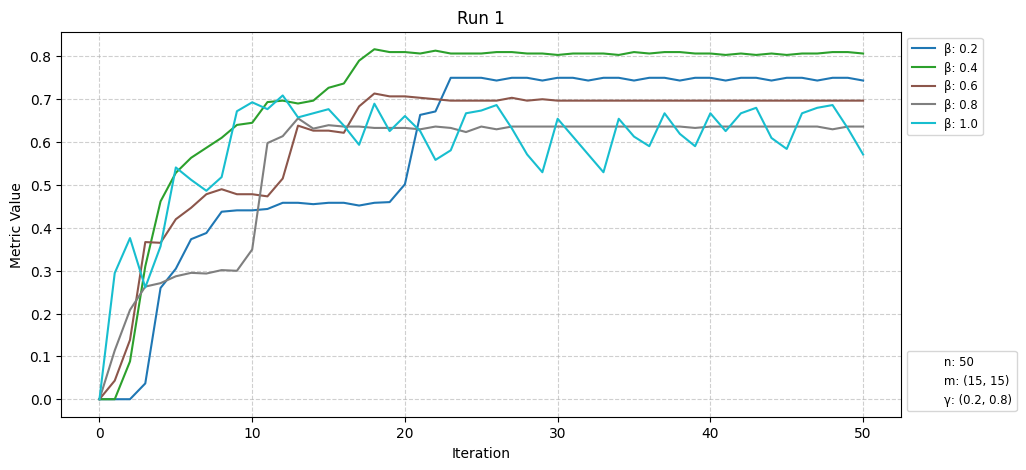

In [17]:
variate_parameters(
    param_space=PARAM_SPACE,
    samples=[],
    varying=['beta','β'],
    fixed={'num_nodes': [50,'n'], 'words_per_node': [(15,15),'m'], 'affinity_level': [0.7,''], 'gamma': [(0.2,0.8),'γ'], 'num_iterations': [50, '']},
    num_runs=1
)

# Ambos Diferentes Por Lado


--- Run 1/1 ---
Base Config:
  influencer_scaling: const_rule
  num_iterations: 50
  num_nodes: 50
  labels: []
  words_per_node: (15, 15)
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  influencer_selection: select_by_max_degree
  gamma: (0.2, 0.8)
  affinity: cosine_similarity
  alphaL: None
  alphaR: None
  affinity_level: 0.7
  bubble_burst_metric_name: cross_group_connectivity
[β: (0.2, 0.8)]
  > First Cross Edge: 1
  > Sample from L (Node 0): [0.03   0.0301 0.0301 0.0301 0.0301 0.0301 0.03   0.0301 0.03   0.0301
 0.0301 0.03   0.0301 0.0301 0.0301 0.0366 0.0366 0.0366 0.0366 0.0366
 0.0366 0.0366 0.0366 0.0366 0.0366 0.0366 0.0366 0.0366 0.0366 0.0366]
  > Sample from R (Node 1): [0.063  0.063  0.063  0.063  0.063  0.063  0.063  0.063  0.063  0.063
 0.063  0.063  0.063  0.063  0.063  0.0037 0.0037 0.0037 0.0037 0.0037
 0.0037 0.0037 0.0037 0.0037 0.0037 0.0037 0.0037 0.0037 0.0037 0.0037]
----------------------------------------
[β

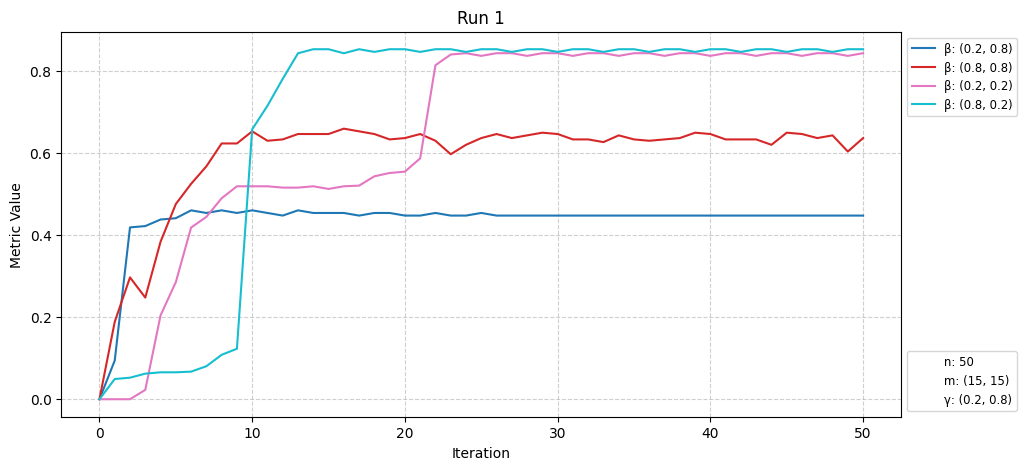

In [18]:
PARAM_SPACE['beta'] = [(0.2,0.8),(0.8,0.8),(0.2,0.2),(0.8,0.2)]
variate_parameters(
    param_space=PARAM_SPACE,
    samples=[],
    varying=['beta','β'],
    fixed={'num_nodes': [50,'n'], 'words_per_node': [(15,15),'m'], 'affinity_level': [0.7,''], 'gamma': [(0.2,0.8),'γ'], 'num_iterations': [50, '']},
    num_runs=1
)


--- Run 1/1 ---
Base Config:
  influencer_scaling: const_rule
  num_iterations: 50
  num_nodes: 50
  labels: []
  words_per_node: (15, 15)
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  influencer_selection: select_by_max_degree
  gamma: (0.2, 0.2)
  affinity: cosine_similarity
  alphaL: None
  alphaR: None
  affinity_level: 0.7
  bubble_burst_metric_name: cross_group_connectivity
[β: (0.2, 0.8)]
  > First Cross Edge: 1
  > Sample from L (Node 1): [0.0306 0.0306 0.0306 0.0306 0.0306 0.0306 0.0306 0.0306 0.0306 0.0306
 0.0306 0.0306 0.0306 0.0306 0.0306 0.036  0.0361 0.0361 0.0361 0.036
 0.036  0.0361 0.0361 0.0361 0.036  0.036  0.0361 0.0361 0.0361 0.036 ]
  > Sample from R (Node 0): [0.0552 0.0552 0.0552 0.0552 0.0552 0.0552 0.0552 0.0552 0.0552 0.0552
 0.0552 0.0552 0.0552 0.0552 0.0552 0.0114 0.0115 0.0115 0.0114 0.0114
 0.0114 0.0114 0.0115 0.0114 0.0114 0.0114 0.0114 0.0114 0.0114 0.0114]
----------------------------------------
[β

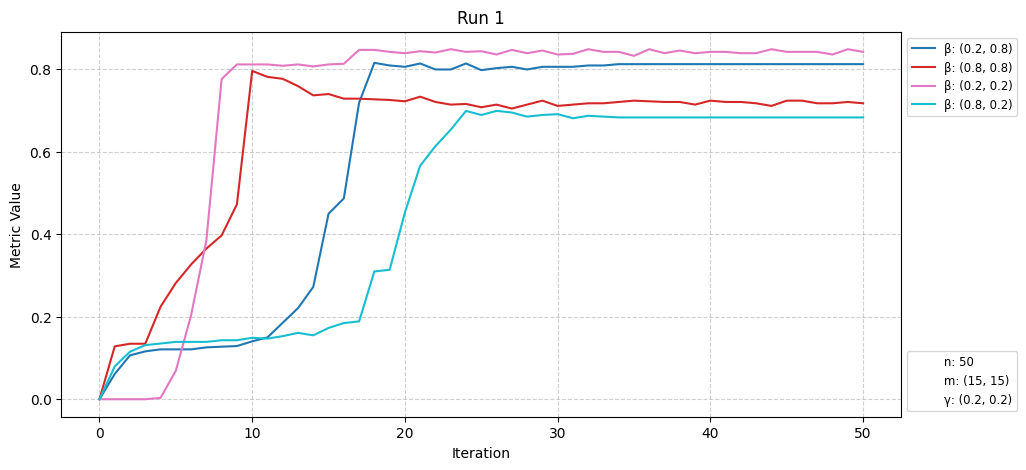

In [19]:
variate_parameters(
    param_space=PARAM_SPACE,
    samples=[],
    varying=['beta','β'],
    fixed={'num_nodes': [50,'n'], 'words_per_node': [(15,15),'m'], 'affinity_level': [0.7,''], 'gamma': [(0.2,0.2),'γ'], 'num_iterations': [50, '']},
    num_runs=1
)


--- Run 1/1 ---
Base Config:
  influencer_scaling: const_rule
  num_iterations: 50
  num_nodes: 50
  labels: []
  words_per_node: (15, 15)
  bubble_burst_metric: cross_group_connectivity
  message_generator: opposite_uniform_message
  influencer_selection: select_by_max_degree
  gamma: (0.8, 0.8)
  affinity: cosine_similarity
  alphaL: None
  alphaR: None
  affinity_level: 0.7
  bubble_burst_metric_name: cross_group_connectivity
[β: (0.2, 0.8)]
  > First Cross Edge: 1
  > Sample from L (Node 0): [0.0373 0.0373 0.0373 0.0373 0.0373 0.0373 0.0373 0.0373 0.0373 0.0373
 0.0373 0.0373 0.0373 0.0373 0.0373 0.0294 0.0294 0.0294 0.0294 0.0294
 0.0294 0.0294 0.0294 0.0294 0.0294 0.0294 0.0294 0.0294 0.0294 0.0294]
  > Sample from R (Node 1): [0.0641 0.0641 0.0641 0.0641 0.0641 0.0641 0.0641 0.0641 0.0641 0.0641
 0.0641 0.0641 0.0641 0.0641 0.0641 0.0026 0.0026 0.0026 0.0026 0.0026
 0.0026 0.0026 0.0026 0.0026 0.0026 0.0026 0.0026 0.0026 0.0026 0.0026]
----------------------------------------
[

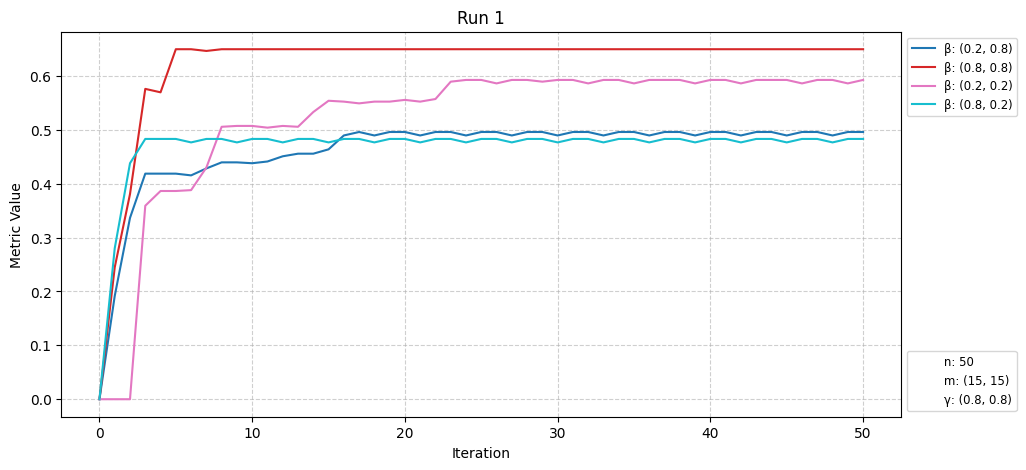

In [20]:
PARAM_SPACE['beta'] = [(0.2,0.8),(0.8,0.8),(0.2,0.2),(0.8,0.2)]
variate_parameters(
    param_space=PARAM_SPACE,
    samples=[],
    varying=['beta','β'],
    fixed={'num_nodes': [50,'n'], 'words_per_node': [(15,15),'m'], 'affinity_level': [0.7,''], 'gamma': [(0.8,0.8),'γ'], 'num_iterations': [50, '']},
    num_runs=1
)